# Klasifikasi Kesegaran Buah Menggunakan Metode GLCM dan Random Forest
## Percobaan 1 — Preprocessing: Resize + Median Filter (2 Preprocessing)
### Nama Anggota
- Thoriq Abdillah Falian Kusuma : F1D02410098
- Jasmine Aulia Santoso : F1D02410010
- Ulul Asmi : F1D002410144
- Fatriya Annastha Putra : F1D02410046

## Import Library

In [22]:
import os
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from skimage.feature import graycomatrix, graycoprops
from scipy.stats import entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import seaborn as sns

## Data Loading

Membaca dataset buah apel dari folder `Dataset/` yang terdiri dari 3 kelas:
- `Fresh_Apple` (Apel Segar)
- `Moderately_Fresh_Apple` (Apel Cukup Segar)
- `Rotten_Apple` (Apel Busuk)

Setiap gambar langsung di-resize ke ukuran 250x250 piksel untuk menyeragamkan dimensi.

In [23]:
def resize_image(image, target_size=(250, 250)):
    return cv.resize(image, target_size)

data = []
labels = []
file_name = []

dataset_path = 'Dataset'

for sub_folder in sorted(os.listdir(dataset_path)):
    folder_path = os.path.join(dataset_path, sub_folder)
    if not os.path.isdir(folder_path):
        continue
    for filename in os.listdir(folder_path):
        img_path = os.path.join(folder_path, filename)
        img = cv.imread(img_path)
        if img is None:
            continue
        img = resize_image(img, (250, 250))
        img = img.astype(np.uint8)
        data.append(img)
        labels.append(sub_folder)
        file_name.append(filename)

data = np.array(data)
labels = np.array(labels)
print(f'Total data: {len(data)}')
print(f'Labels: {np.unique(labels)}')

Total data: 828
Labels: ['Fresh_Apple' 'Moderately_Fresh_Apple' 'Rotten_Apple']


## Data Understanding

### Distribusi Data
Menampilkan jumlah gambar per kelas untuk memahami keseimbangan dataset.

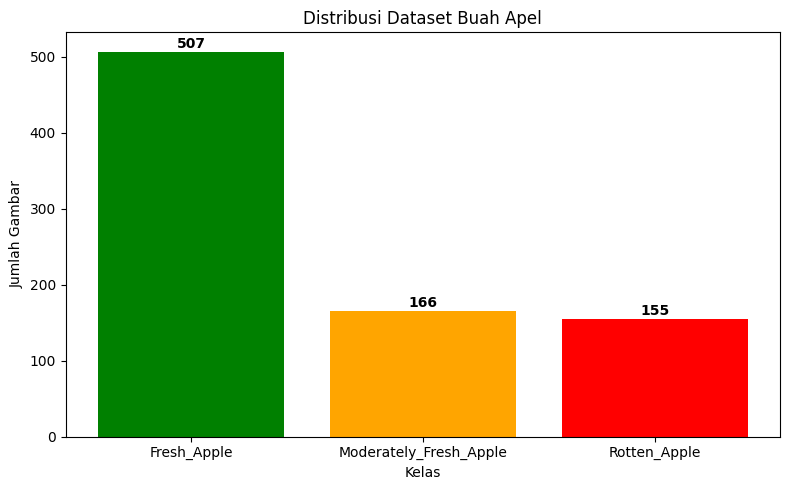

In [24]:
unique, counts = np.unique(labels, return_counts=True)
plt.figure(figsize=(8, 5))
plt.bar(unique, counts, color=['green', 'orange', 'red'])
plt.xlabel('Kelas')
plt.ylabel('Jumlah Gambar')
plt.title('Distribusi Dataset Buah Apel')
for i, (u, c) in enumerate(zip(unique, counts)):
    plt.text(i, c + 5, str(c), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### Sample Data
Menampilkan contoh gambar dari setiap kelas.

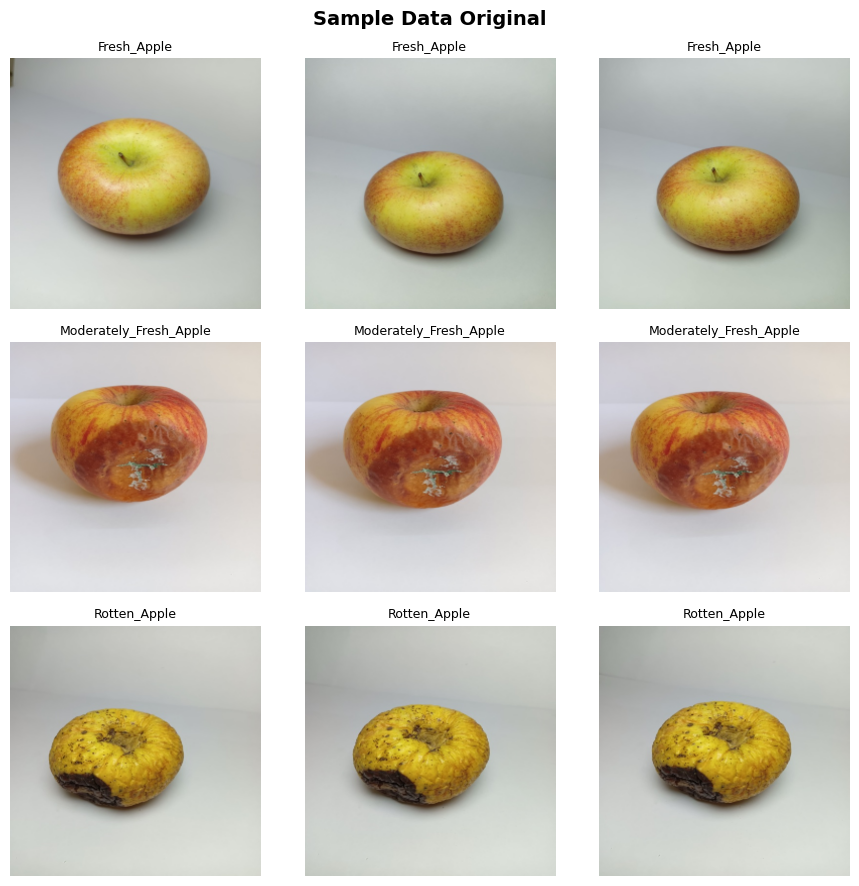

In [25]:
def show_sample_images(images, labels, class_names, title='Sample Images', n=3):
    fig, axes = plt.subplots(len(class_names), n, figsize=(n*3, len(class_names)*3))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for i, cls in enumerate(class_names):
        idx = np.where(labels == cls)[0]
        for j in range(min(n, len(idx))):
            img = images[idx[j]]
            if len(img.shape) == 3:
                axes[i][j].imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
            else:
                axes[i][j].imshow(img, cmap='gray')
            axes[i][j].set_title(f'{cls}', fontsize=9)
            axes[i][j].axis('off')
    plt.tight_layout()
    plt.show()

class_names = sorted(np.unique(labels))
show_sample_images(data, labels, class_names, 'Sample Data Original')

## Grayscale
Mengubah semua gambar dari BGR ke Grayscale karena GLCM memerlukan gambar 1-channel.

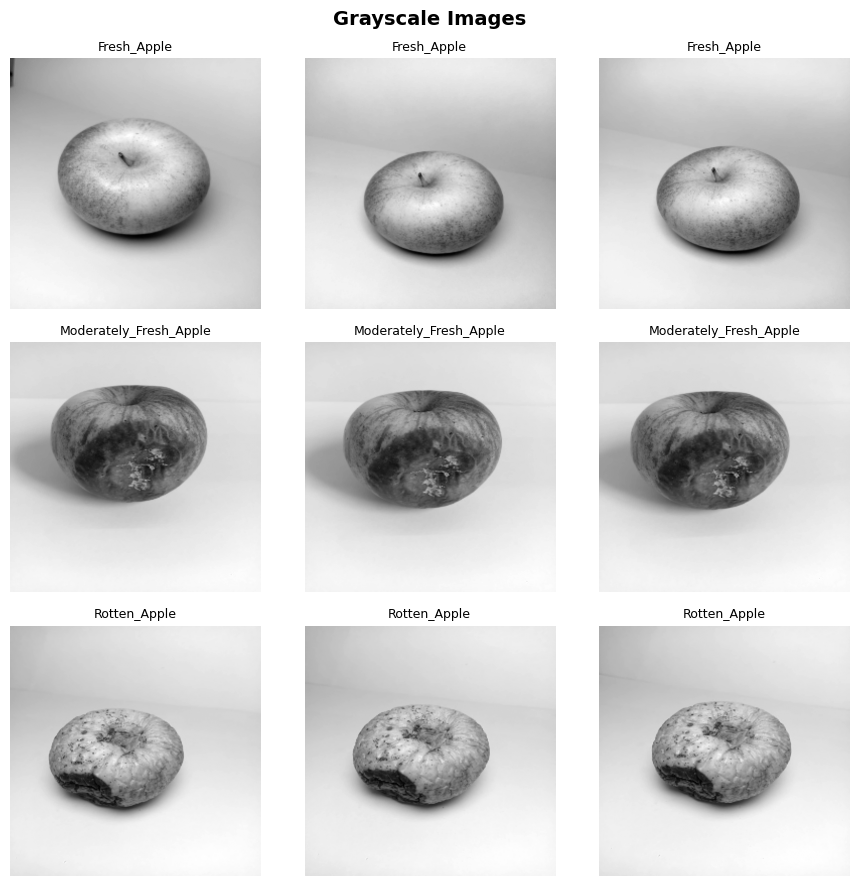

In [26]:
img_grey = []
for img in data:
    gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
    img_grey.append(gray)
img_grey = np.array(img_grey)

show_sample_images(img_grey, labels, class_names, 'Grayscale Images')

## Preprocessing 1: Resize + Median Filter
Pada percobaan 1, hanya digunakan 2 preprocessing:
1. **Resize** (sudah dilakukan saat data loading ke ukuran 250x250)
2. **Median Filter** — untuk menghilangkan noise salt & pepper pada gambar

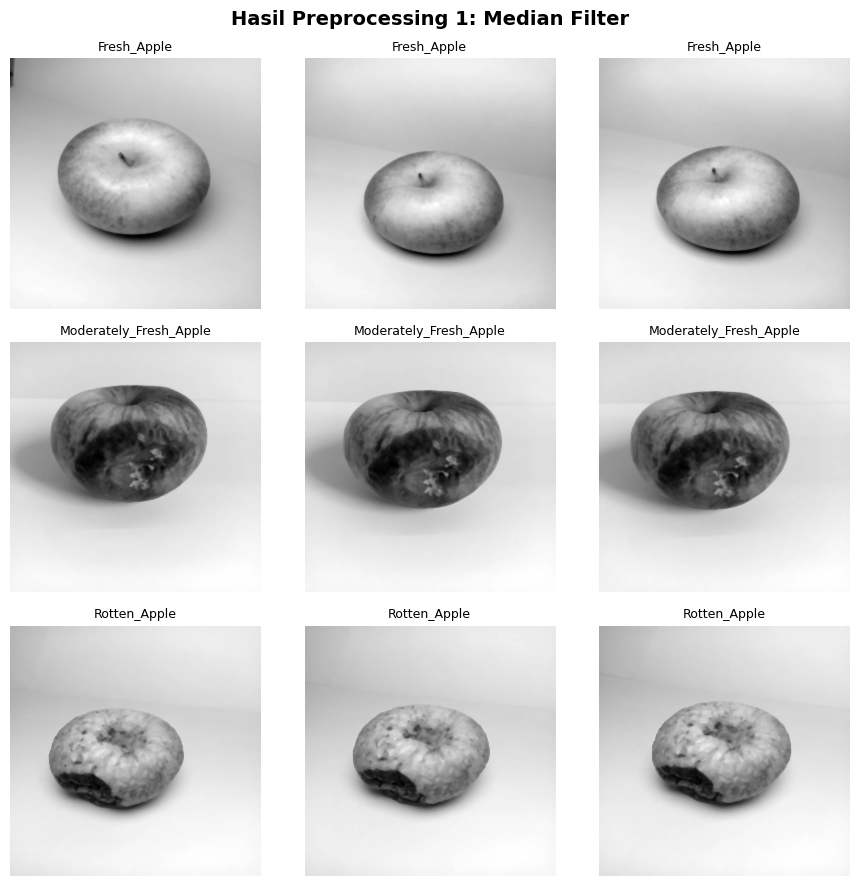

In [27]:
# Fungsi Median Filter
def hitung_median(image):
    return np.median(image)

def median_filter(image, kernel_size=3):
    pad = kernel_size // 2
    padded = np.pad(image, pad, mode='reflect')
    result = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            window = padded[i:i+kernel_size, j:j+kernel_size]
            result[i, j] = hitung_median(window)
    return result.astype(np.uint8)

# Menerapkan Median Filter
dataPreprocessed = []
for img in img_grey:
    filtered = median_filter(img, kernel_size=3)
    dataPreprocessed.append(filtered)
dataPreprocessed = np.array(dataPreprocessed)

show_sample_images(dataPreprocessed, labels, class_names, 'Hasil Preprocessing 1: Median Filter')

## Feature Extraction — GLCM
Mengekstrak 7 fitur tekstur dari GLCM pada 4 sudut (0°, 45°, 90°, 135°):
- Contrast, Dissimilarity, Homogeneity, Entropy, ASM, Energy, Correlation

Total: 7 fitur × 4 sudut = **28 fitur per gambar**

In [28]:
def glcm(image, derajat):
    if derajat == 0:
        angles = [0]
    elif derajat == 45:
        angles = [np.pi / 4]
    elif derajat == 90:
        angles = [np.pi / 2]
    elif derajat == 135:
        angles = [3 * np.pi / 4]
    else:
        raise ValueError("Invalid angle. Should be 0, 45, 90, or 135.")
    glcm_matrix = graycomatrix(image, [1], angles, 256, symmetric=True, normed=True)
    return glcm_matrix

def correlation(matriks):
    return graycoprops(matriks, 'correlation')[0, 0]

def dissimilarity(matriks):
    return graycoprops(matriks, 'dissimilarity')[0, 0]

def homogenity(matriks):
    return graycoprops(matriks, 'homogeneity')[0, 0]

def contrast(matriks):
    return graycoprops(matriks, 'contrast')[0, 0]

def ASM(matriks):
    return graycoprops(matriks, 'ASM')[0, 0]

def energy(matriks):
    return graycoprops(matriks, 'energy')[0, 0]

def entropyGlcm(matriks):
    return entropy(matriks.ravel())

### Hitung GLCM untuk setiap gambar pada 4 sudut

In [29]:
Derajat0 = []
Derajat45 = []
Derajat90 = []
Derajat135 = []
for i in range(len(dataPreprocessed)):
    D0 = glcm(dataPreprocessed[i], 0)
    D45 = glcm(dataPreprocessed[i], 45)
    D90 = glcm(dataPreprocessed[i], 90)
    D135 = glcm(dataPreprocessed[i], 135)
    Derajat0.append(D0)
    Derajat45.append(D45)
    Derajat90.append(D90)
    Derajat135.append(D135)
print(f'GLCM computed for {len(Derajat0)} images')

GLCM computed for 828 images


### Ekstraksi 7 Fitur dari GLCM

In [30]:
Kontras0, Kontras45, Kontras90, Kontras135 = [], [], [], []
dissimilarity0, dissimilarity45, dissimilarity90, dissimilarity135 = [], [], [], []
homogenity0, homogenity45, homogenity90, homogenity135 = [], [], [], []
entropy0, entropy45, entropy90, entropy135 = [], [], [], []
ASM0, ASM45, ASM90, ASM135 = [], [], [], []
energy0, energy45, energy90, energy135 = [], [], [], []
correlation0, correlation45, correlation90, correlation135 = [], [], [], []

for i in range(len(dataPreprocessed)):
    # Correlation
    correlation0.append(correlation(Derajat0[i]))
    correlation45.append(correlation(Derajat45[i]))
    correlation90.append(correlation(Derajat90[i]))
    correlation135.append(correlation(Derajat135[i]))
    # Contrast
    Kontras0.append(contrast(Derajat0[i]))
    Kontras45.append(contrast(Derajat45[i]))
    Kontras90.append(contrast(Derajat90[i]))
    Kontras135.append(contrast(Derajat135[i]))
    # Dissimilarity
    dissimilarity0.append(dissimilarity(Derajat0[i]))
    dissimilarity45.append(dissimilarity(Derajat45[i]))
    dissimilarity90.append(dissimilarity(Derajat90[i]))
    dissimilarity135.append(dissimilarity(Derajat135[i]))
    # Homogeneity
    homogenity0.append(homogenity(Derajat0[i]))
    homogenity45.append(homogenity(Derajat45[i]))
    homogenity90.append(homogenity(Derajat90[i]))
    homogenity135.append(homogenity(Derajat135[i]))
    # Entropy
    entropy0.append(entropyGlcm(Derajat0[i]))
    entropy45.append(entropyGlcm(Derajat45[i]))
    entropy90.append(entropyGlcm(Derajat90[i]))
    entropy135.append(entropyGlcm(Derajat135[i]))
    # ASM
    ASM0.append(ASM(Derajat0[i]))
    ASM45.append(ASM(Derajat45[i]))
    ASM90.append(ASM(Derajat90[i]))
    ASM135.append(ASM(Derajat135[i]))
    # Energy
    energy0.append(energy(Derajat0[i]))
    energy45.append(energy(Derajat45[i]))
    energy90.append(energy(Derajat90[i]))
    energy135.append(energy(Derajat135[i]))

print('Feature extraction completed!')

Feature extraction completed!


### Simpan Hasil Ekstraksi ke CSV

In [31]:
dataTable = {'Filename': file_name, 'Label': labels,
        'Contrast0': Kontras0, 'Contrast45': Kontras45, 'Contrast90': Kontras90, 'Contrast135': Kontras135,
        'Homogeneity0': homogenity0, 'Homogeneity45': homogenity45, 'Homogeneity90': homogenity90, 'Homogeneity135': homogenity135,
        'Dissimilarity0': dissimilarity0, 'Dissimilarity45': dissimilarity45, 'Dissimilarity90': dissimilarity90, 'Dissimilarity135': dissimilarity135,
        'Entropy0': entropy0, 'Entropy45': entropy45, 'Entropy90': entropy90, 'Entropy135': entropy135,
        'ASM0': ASM0, 'ASM45': ASM45, 'ASM90': ASM90, 'ASM135': ASM135,
        'Energy0': energy0, 'Energy45': energy45, 'Energy90': energy90, 'Energy135': energy135,
        'Correlation0': correlation0, 'Correlation45': correlation45, 'Correlation90': correlation90, 'Correlation135': correlation135
        }
df = pd.DataFrame(dataTable)
df.to_csv('hasil_ekstraksi_percobaan1.csv', index=False)

hasilEkstrak = pd.read_csv('hasil_ekstraksi_percobaan1.csv')
hasilEkstrak

,Filename,Label,Contrast0,Contrast45,Contrast90,Contrast135,Homogeneity0,Homogeneity45,Homogeneity90,Homogeneity135,...,ASM90,ASM135,Energy0,Energy45,Energy90,Energy135,Correlation0,Correlation45,Correlation90,Correlation135
0,IMG20260204225626.jpg,Fresh_Apple,6.326635,14.632699,9.238442,13.679360,0.747351,0.663869,0.687919,0.643783,...,0.004902,0.004121,0.080278,0.070151,0.070013,0.064196,0.996286,0.991420,0.994585,0.991978
1,IMG20260204225637.jpg,Fresh_Apple,6.434378,15.911227,10.564562,14.777326,0.779185,0.676222,0.706611,0.673998,...,0.006347,0.005673,0.091952,0.076995,0.079669,0.075321,0.995439,0.988738,0.992505,0.989540
2,IMG20260204225638.jpg,Fresh_Apple,6.798313,16.548362,10.804498,15.113982,0.786652,0.685084,0.709890,0.675669,...,0.006410,0.005700,0.093837,0.078463,0.080061,0.075499,0.995322,0.988630,0.992558,0.989616
3,IMG20260204225640.jpg,Fresh_Apple,7.254410,17.398687,11.141494,15.543862,0.772061,0.682698,0.705197,0.663538,...,0.006600,0.005728,0.093181,0.080476,0.081243,0.075687,0.995272,0.988680,0.992735,0.989887
4,IMG20260204225642.jpg,Fresh_Apple,7.363695,18.238270,11.555052,16.029677,0.764086,0.679342,0.702648,0.657922,...,0.006259,0.005397,0.090039,0.078551,0.079113,0.073465,0.995445,0.988728,0.992869,0.990093
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
823,IMG20260409232001.jpg,Rotten_Apple,13.196032,28.975065,16.641783,22.754294,0.797611,0.705078,0.736019,0.713990,...,0.006133,0.005766,0.090241,0.075180,0.078315,0.075933,0.993281,0.985269,0.991518,0.988432
824,IMG20260409232002.jpg,Rotten_Apple,15.106940,32.248028,18.350024,25.256964,0.788732,0.693761,0.729112,0.710537,...,0.006273,0.005974,0.090875,0.075232,0.079202,0.077294,0.992030,0.983010,0.990306,0.986693
825,IMG20260409232003.jpg,Rotten_Apple,14.090217,30.895727,17.678153,24.020709,0.795618,0.700601,0.733321,0.715190,...,0.006371,0.006054,0.091640,0.076103,0.079818,0.077806,0.992572,0.983735,0.990668,0.987355
826,IMG20260409232005.jpg,Rotten_Apple,15.598876,32.470847,18.934088,26.658441,0.790538,0.702646,0.734453,0.710767,...,0.007424,0.006932,0.097693,0.082680,0.086164,0.083258,0.992627,0.984687,0.991043,0.987428


## Feature Selection
Menggunakan Correlation Matrix untuk menghilangkan fitur yang redundan (korelasi > 0.95).

Fitur sebelum seleksi: 28
Fitur setelah seleksi: 12
Fitur terpilih: ['Contrast0', 'Contrast45', 'Contrast90', 'Contrast135', 'Homogeneity0', 'Homogeneity45', 'Dissimilarity0', 'Entropy0', 'ASM0', 'Correlation0', 'Correlation45', 'Correlation135']


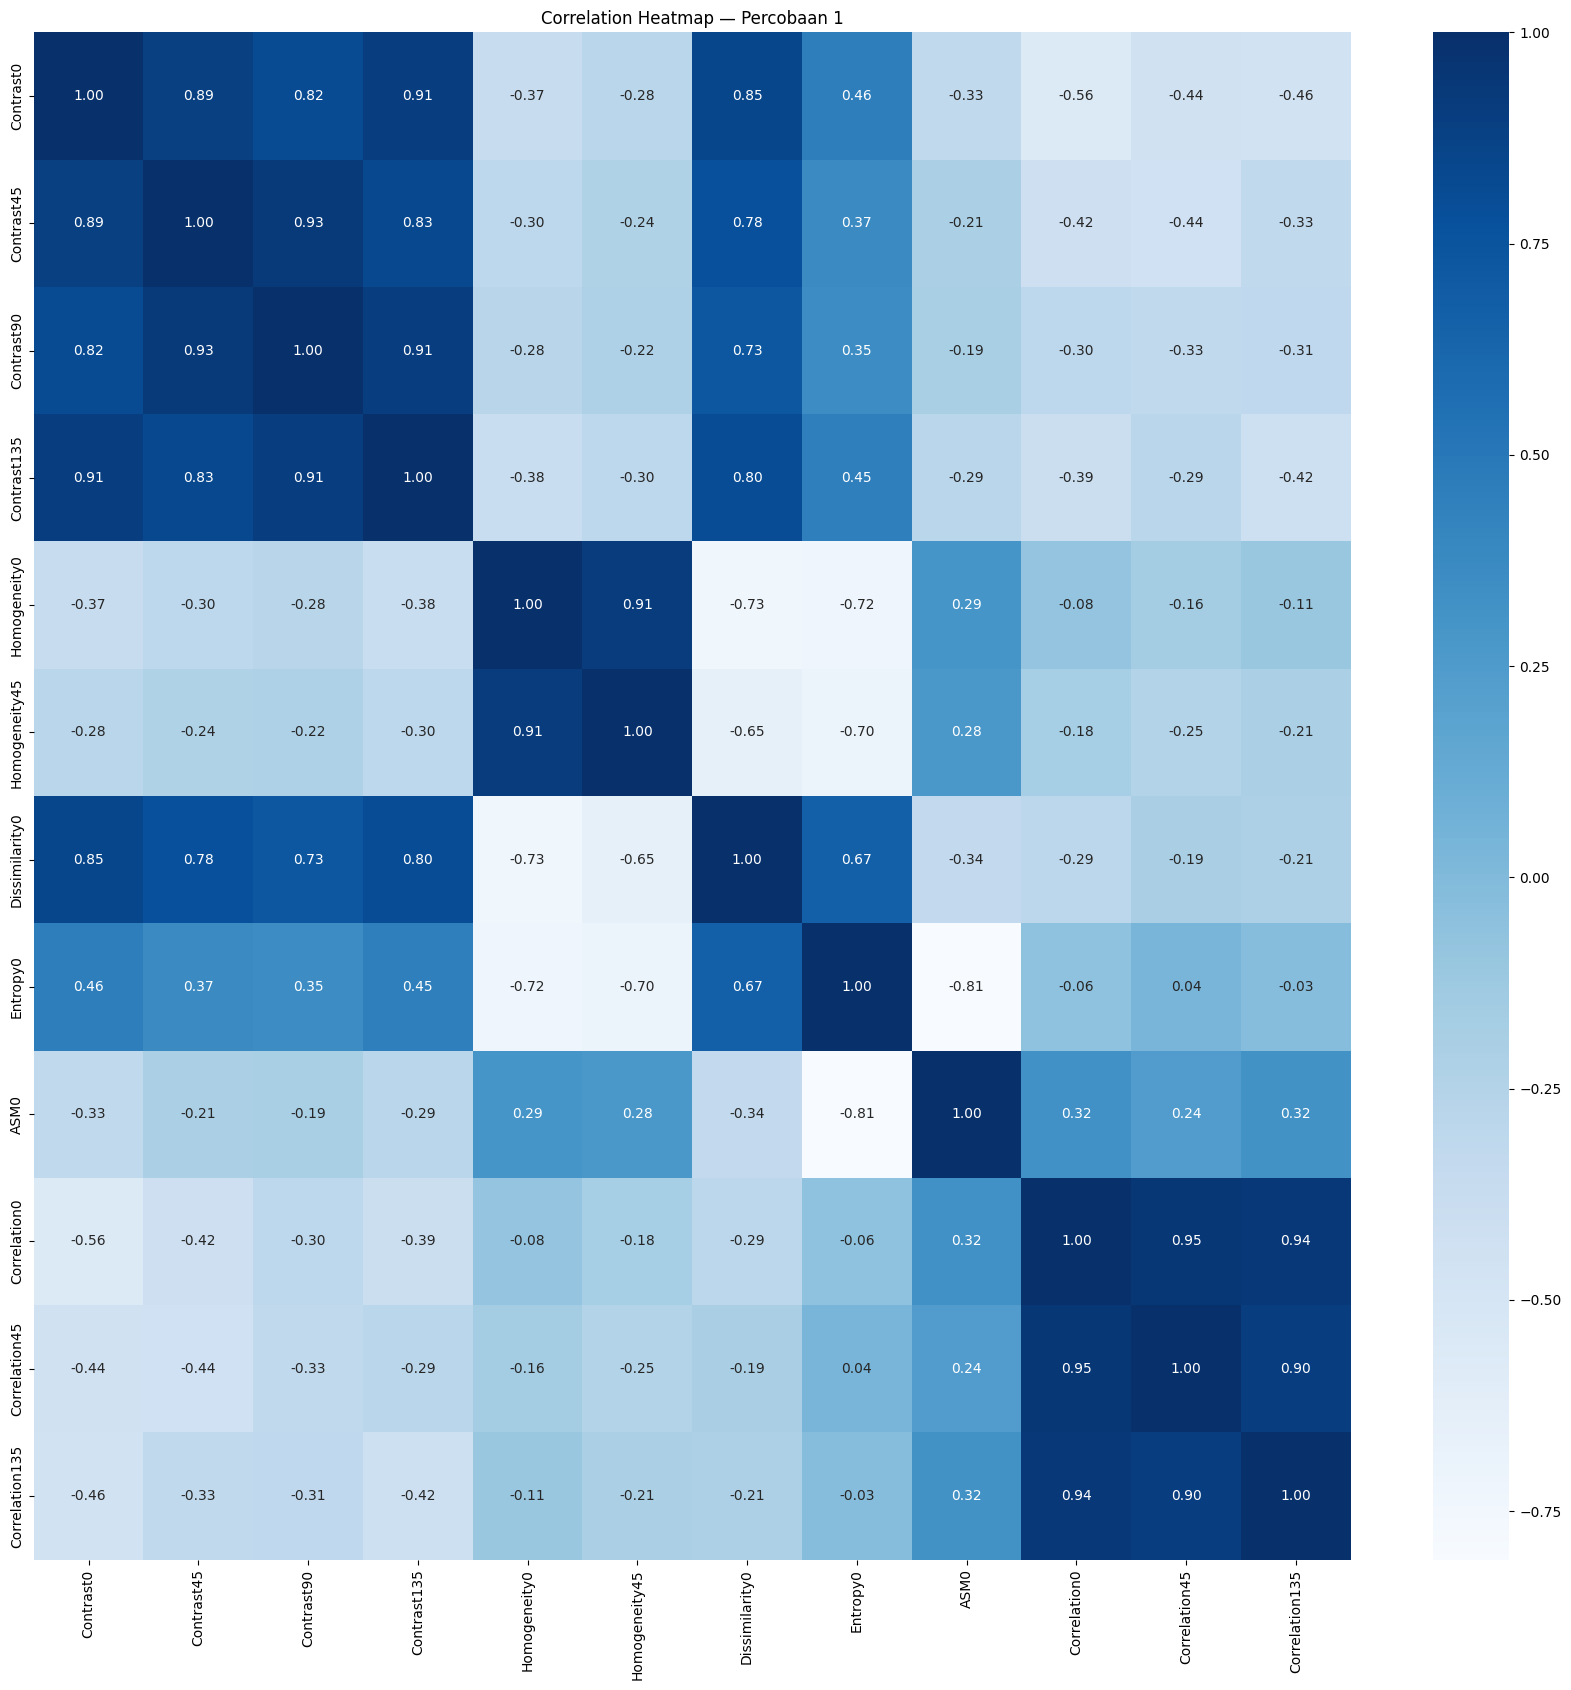

In [32]:
correlation_matrix = hasilEkstrak.drop(columns=['Label','Filename']).corr()

threshold = 0.95
columns = np.full((correlation_matrix.shape[0],), True, dtype=bool)
for i in range(correlation_matrix.shape[0]):
    for j in range(i+1, correlation_matrix.shape[0]):
        if correlation_matrix.iloc[i,j] >= threshold:
            if columns[j]:
                columns[j] = False

select = hasilEkstrak.drop(columns=['Label','Filename']).columns[columns]
x_new = hasilEkstrak[select]
y = hasilEkstrak['Label']

print(f'Fitur sebelum seleksi: {len(hasilEkstrak.columns) - 2}')
print(f'Fitur setelah seleksi: {len(select)}')
print(f'Fitur terpilih: {list(select)}')

plt.figure(figsize=(17,17))
sns.heatmap(x_new.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Heatmap — Percobaan 1')
plt.tight_layout()
plt.show()

## Splitting Data
Membagi data menjadi 80% training dan 20% testing.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(x_new, y, test_size=0.2, random_state=42)
print(f'Training set: {X_train.shape}')
print(f'Testing set: {X_test.shape}')

Training set: (662, 12)
Testing set: (166, 12)


## Feature Normalization
Normalisasi menggunakan Standardization (Z-score).

In [34]:
X_test = (X_test - X_train.mean()) / X_train.std()
X_train = (X_train - X_train.mean()) / X_train.std()

## Modeling
Melatih 3 model klasifikasi: Random Forest, SVM, dan KNN.

In [35]:
def generateClassificationReport(y_true, y_pred):
    print(classification_report(y_true, y_pred))
    print('Accuracy:', accuracy_score(y_true, y_pred))

# Define classifiers
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svm = SVC(kernel='rbf', random_state=42)
knn = KNeighborsClassifier(n_neighbors=5)

### Train Random Forest Classifier

In [36]:
rf.fit(X_train, y_train)

print("------Training Set------")
y_pred = rf.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_rf = rf.predict(X_test)
generateClassificationReport(y_test, y_pred_rf)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       1.00      1.00      1.00       409
Moderately_Fresh_Apple       1.00      1.00      1.00       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           1.00       662
             macro avg       1.00      1.00      1.00       662
          weighted avg       1.00      1.00      1.00       662

Accuracy: 1.0

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.93      1.00      0.97        98
Moderately_Fresh_Apple       1.00      0.82      0.90        33
          Rotten_Apple       1.00      0.97      0.99        35

              accuracy                           0.96       166
             macro avg       0.98      0.93      0.95       166
          weighted avg       0.96      0.96      0.96       166

Accuracy: 0.9578313253012049


### Train SVM Classifier

In [37]:
svm.fit(X_train, y_train)

print("------Training Set------")
y_pred = svm.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_svm = svm.predict(X_test)
generateClassificationReport(y_test, y_pred_svm)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.94      0.96      0.95       409
Moderately_Fresh_Apple       0.86      0.80      0.83       133
          Rotten_Apple       1.00      1.00      1.00       120

              accuracy                           0.93       662
             macro avg       0.93      0.92      0.93       662
          weighted avg       0.93      0.93      0.93       662

Accuracy: 0.9335347432024169

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.90      0.98      0.94        98
Moderately_Fresh_Apple       0.92      0.67      0.77        33
          Rotten_Apple       1.00      1.00      1.00        35

              accuracy                           0.92       166
             macro avg       0.94      0.88      0.90       166
          weighted avg       0.92      0.92      0.92       166

Accuracy: 0.9216867

### Train KNN Classifier

In [38]:
knn.fit(X_train, y_train)

print("------Training Set------")
y_pred = knn.predict(X_train)
generateClassificationReport(y_train, y_pred)

print("\n------Testing Set------")
y_pred_knn = knn.predict(X_test)
generateClassificationReport(y_test, y_pred_knn)

------Training Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.97      0.95      0.96       409
Moderately_Fresh_Apple       0.85      0.91      0.88       133
          Rotten_Apple       0.99      1.00      1.00       120

              accuracy                           0.95       662
             macro avg       0.94      0.95      0.94       662
          weighted avg       0.95      0.95      0.95       662

Accuracy: 0.9486404833836858

------Testing Set------
                        precision    recall  f1-score   support

           Fresh_Apple       0.94      0.95      0.94        98
Moderately_Fresh_Apple       0.87      0.82      0.84        33
          Rotten_Apple       0.97      1.00      0.99        35

              accuracy                           0.93       166
             macro avg       0.93      0.92      0.92       166
          weighted avg       0.93      0.93      0.93       166

Accuracy: 0.9337349

## Evaluation — Confusion Matrix

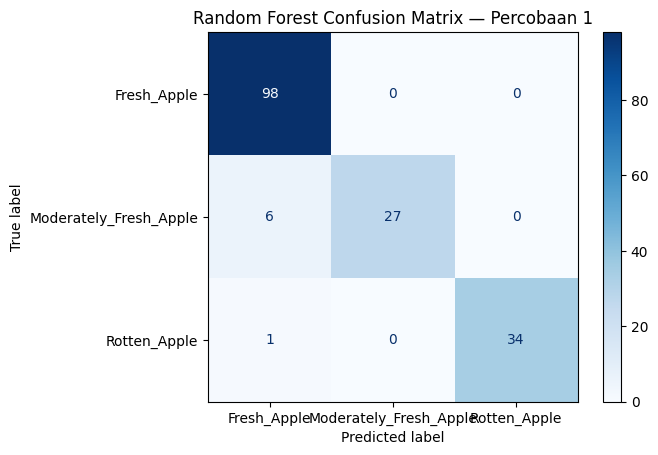

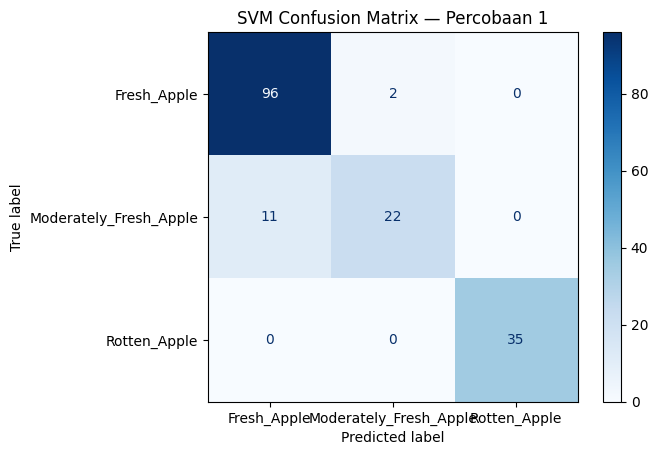

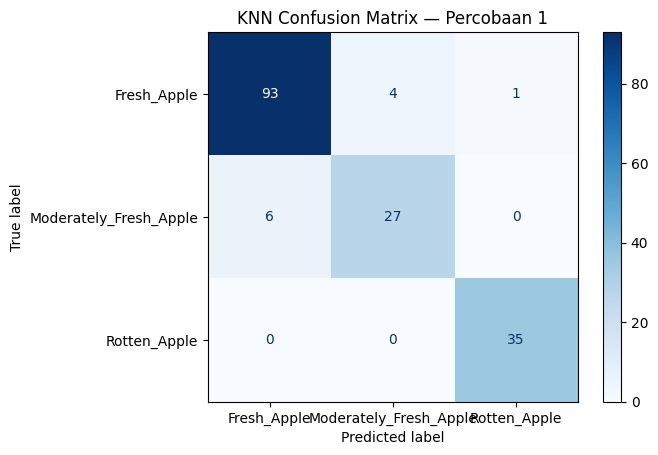

In [39]:
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=sorted(np.unique(y_true)))
    disp.plot(cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest Confusion Matrix — Percobaan 1')
plot_confusion_matrix(y_test, y_pred_svm, 'SVM Confusion Matrix — Percobaan 1')
plot_confusion_matrix(y_test, y_pred_knn, 'KNN Confusion Matrix — Percobaan 1')

## Ringkasan Hasil Percobaan 1

In [40]:
print('=== RINGKASAN HASIL PERCOBAAN 1 ===')
print(f'Preprocessing: Resize (250x250) + Median Filter (3x3)')
print(f'Jumlah Fitur Setelah Seleksi: {X_train.shape[1]}')
print(f'\nAkurasi Testing Set:')
print(f'  Random Forest : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'  SVM           : {accuracy_score(y_test, y_pred_svm):.4f}')
print(f'  KNN           : {accuracy_score(y_test, y_pred_knn):.4f}')

=== RINGKASAN HASIL PERCOBAAN 1 ===
Preprocessing: Resize (250x250) + Median Filter (3x3)
Jumlah Fitur Setelah Seleksi: 12

Akurasi Testing Set:
  Random Forest : 0.9578
  SVM           : 0.9217
  KNN           : 0.9337
